Epoch 1/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 2/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 3/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 4/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - loss: 0.0012 - val_loss: 9.1536e-04
Epoch 5/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 53s 12ms/step - loss: 0.0011 - val_loss: 9.4432e-04
Epoch 6/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - loss: 0.0011 - val_loss: 9.3330e-04
Epoch 7/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 52s 12ms/step - loss: 9.7882e-04 - val_loss: 8.7071e-04
Epoch 8/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 52s 12ms/step - loss: 9.2762e-04 - val_loss: 8.7094e-04
Epoch 9/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - loss: 9.0429e-04 - val_loss: 0.0012
Epoch 10/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 52s 12ms/step - loss: 9.3001e-04 - val_loss: 7.9410e-04
Epoch 11/30
4382/4382 ━━━━━━━━━━━━━━━━━━━━ 55s 13ms/step - 

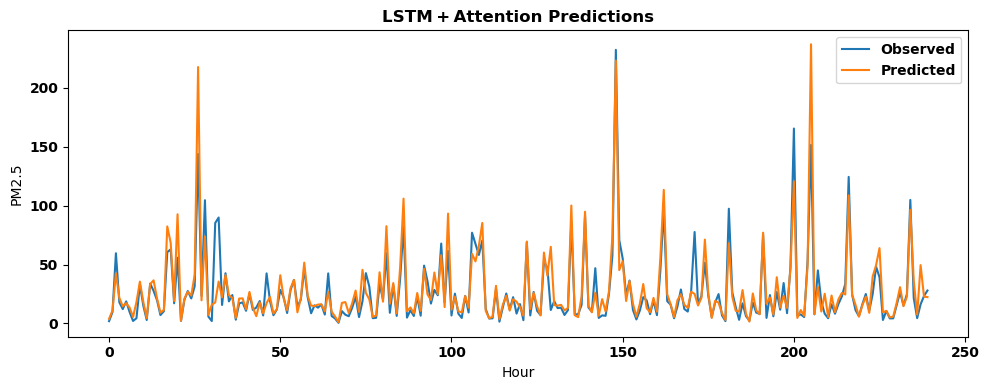

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


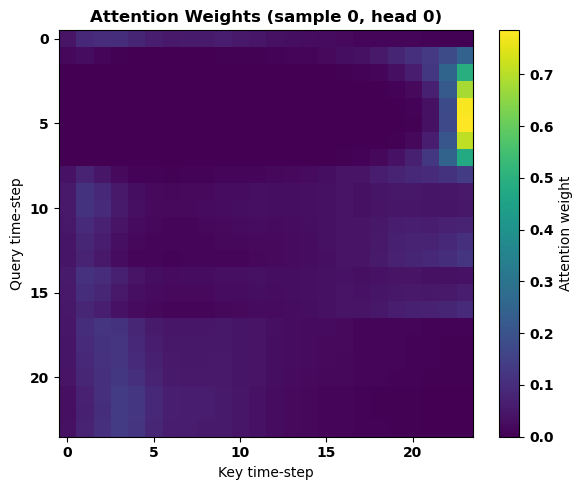

In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib import rcParams
from keras.layers import Input, LSTM, MultiHeadAttention, Dense, Flatten
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1) Load data
dataset = pd.read_csv("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/AirData/eMalahleniIM.csv", sep=';', header=0, index_col=0)
values = dataset.values.astype('float32')

# 2) helper: frame time series as supervised
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    df = pd.DataFrame(data)
    cols, names = [], []
    n_vars = df.shape[1]
    # input lags
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]
    # forecast
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        names += [f'var{j+1}(t{"" if i==0 else f"+{i}"})' for j in range(n_vars)]
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    if dropnan: agg.dropna(inplace=True)
    return agg

# 3) normalize
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(values)

# 4) supervised framing
n_in, n_vars = 24, scaled.shape[1]
reframed = series_to_supervised(scaled, n_in, 1)

# 5) select lagged inputs + first var as target
n_obs = n_in * n_vars
df_trim = reframed.iloc[:, list(range(n_obs)) + [n_obs]]
vals = df_trim.values
X_all, Y_all = vals[:, :n_obs], vals[:, -1]

# 6) reshape [samples, timesteps, features]
X = X_all.reshape((X_all.shape[0], n_in, n_vars))
Y = Y_all

# 7) train/val/test split
X_train, X_tmp, Y_train, Y_tmp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_tmp, Y_tmp, test_size=0.5, random_state=42)

# 8) build & train regression model with MHA
inp = Input(shape=(n_in, n_vars), name='inputs')
lstm = LSTM(56, return_sequences=True, name='lstm')(inp)
mha_layer = MultiHeadAttention(num_heads=4, key_dim=56, name='mha')
ctx = mha_layer(query=lstm, value=lstm, key=lstm)
flat = Flatten(name='flatten')(ctx)
x = Dense(56, activation='relu')(flat)
x = Dense(56, activation='relu')(x)
x = Dense(56, activation='relu')(x)
x = Dense(56, activation='relu')(x)
x = Dense(56, activation='relu')(x)
out = Dense(1, activation='linear', name='pred')(x)

model = Model(inputs=inp, outputs=out)
model.compile(loss='mse', optimizer='adam')
model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=30, batch_size=16, verbose=1)

# 9) build inference model for attention scores
inf_inp = Input(shape=(n_in, n_vars), name='inf_inputs')
inf_lstm = model.get_layer('lstm')(inf_inp)
_, attn_scores = mha_layer(
    query=inf_lstm,
    value=inf_lstm,
    key=inf_lstm,
    return_attention_scores=True)
attn_model = Model(inputs=inf_inp, outputs=attn_scores)

# 10) predict & un‑scale
pred_sc = model.predict(X_test)
y_pred = pred_sc.flatten() * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]
y_true = Y_test * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

# 11) metrics
mae  = mean_absolute_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

# 12) plot observed vs. predicted
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(10,4))
plt.plot(y_true[:240], label='Observed')
plt.plot(y_pred[:240], label='Predicted')
plt.title('LSTM + Attention Predictions', fontweight='bold')
plt.xlabel('Hour'); plt.ylabel('PM2.5')
plt.legend(); plt.tight_layout(); plt.show()

# 13) extract & plot attention heatmap (sample 0, head 0)
scores = attn_model.predict(X_test)
# scores shape: (n_samples, n_heads, Tq, Tk)
attn0 = scores[0, 0, :, :]   # pick sample 0, head 0
plt.figure(figsize=(6,5))
plt.imshow(attn0, aspect='auto', cmap='viridis')
plt.colorbar(label='Attention weight')
plt.xlabel('Key time‑step'); plt.ylabel('Query time‑step')
plt.title('Attention Weights (sample 0, head 0)', fontweight='bold')
plt.tight_layout(); plt.show()


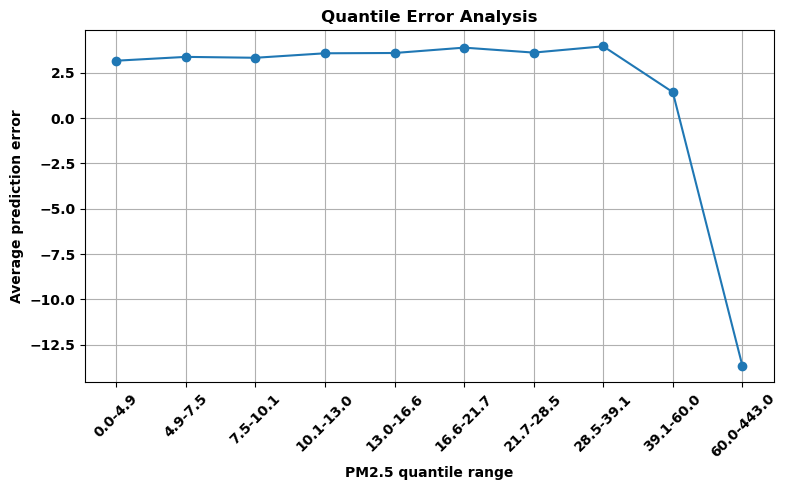

In [2]:
# 14) quantile error analysis
errors = y_pred - y_true
quantiles, bins = pd.qcut(y_true, 10, duplicates='drop', retbins=True)
quantile_errors = [
    errors[(y_true >= bins[i]) & (y_true < bins[i+1])].mean()
    for i in range(len(bins)-1)
]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(quantile_errors)+1), quantile_errors, marker='o')
plt.xticks(
    range(1, len(quantile_errors)+1),
    [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)],
    rotation=45
)
plt.xlabel('PM2.5 quantile range', fontweight='bold')
plt.ylabel('Average prediction error', fontweight='bold')
plt.title('Quantile Error Analysis', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
6888/6888 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step
1/1 ━━━━━━━━━━━━

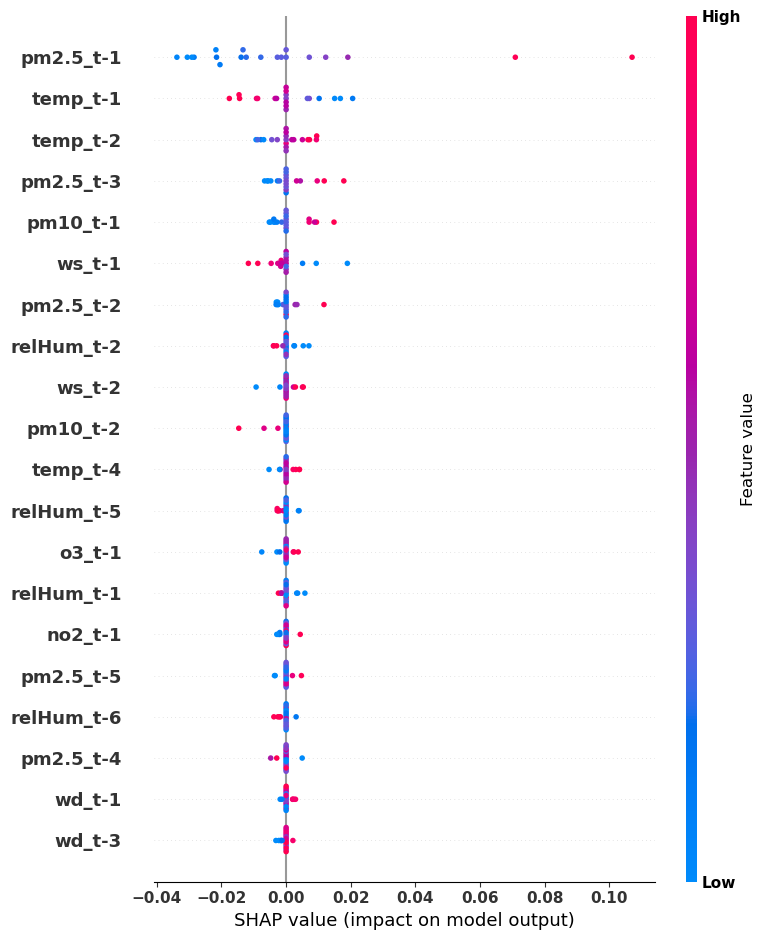

In [3]:
import shap  # ← now import shap, *after* training is done

# Prepare flattened background & test data
bg_idx  = np.random.choice(X_train.shape[0], 100, replace=False)
bg_flat = X_train[bg_idx].reshape(100, n_in*n_vars)
ts_idx  = np.random.choice(X_test.shape[0], 20, replace=False)
test_flat = X_test[ts_idx].reshape(20, n_in*n_vars)

# Prediction function for flattened input
f = lambda x: model.predict(x.reshape((x.shape[0], n_in, n_vars))).flatten()

explainer   = shap.KernelExplainer(f, bg_flat)
shap_values = explainer.shap_values(test_flat)

# Feature names in the same order as flattened array
cols = dataset.columns.tolist()
feat_names = [f"{col}_t-{lag}" 
              for lag in range(n_in, 0, -1) 
              for col in cols]

# Summary plot
shap.summary_plot(shap_values, test_flat, feature_names=feat_names)
